# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

## Постановка задачи

Теперь настало время самостоятельной работы. В рамках самостоятельной работы вам предстоит решить задачу прогнозирования оттока клиентов банка. 

> **Примечание.** Вы уже знакомились с этой задачей в модуле по визуализации («PYTHON-13. Визуализация данных») и провели небольшое исследование данных. Вы можете использовать результаты своего исследования для построения модели машинного обучения.

Напомним контекст задачи:

> Некоторый банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдёт ли клиент в ближайшее время. 

Итак, ранее вы провели небольшой разведывательный анализ, познакомились с данными и выявили, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов. Вы отлично справились с первой задачей, и теперь представители банка предлагают вам построить саму модель машинного обучения, которая будет прогнозировать отток клиентов. 

**Ваша задача** - построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

Разделим эту задачу на две части:
* В первой части мы подготовим данные для моделирования и построим простейшую модель логистической регрессии, оценим её качество и проанализируем результаты её работы.

* Во второй части мы займёмся построением моделей дерева решений и случайного леса, сравним их результаты с результатами, полученными на первом этапе, и сделаем финальный вывод.


Для начала импортируем библиотеки, которые нам понадобятся:

In [ ]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
%matplotlib inline

Итак, прочитаем нашу таблицу:

In [2]:
churn_data = pd.read_csv(r"C:\Users\aleks\Downloads\ML-3_churn\churn.csv")
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Практика: логистическая регрессия

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9:

### Задание 5.0 (не оценивается)

Для полноты задачи проведите небольшой разведывательный анализ данных. Постройте графики распределения целевого признака, диаграммы и графики, показывающие взаимосвязь между исходными признаками и целевым признаком, а также другие диаграммы, иллюстрирующие предоставленные данные. 

**Совет:** воспользуйтесь кодом, который вы писали, выполняя задания в модуле «PYTHON-13. Визуализация данных».

Размер датасета: (10000, 14)

Первые 5 строк:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       

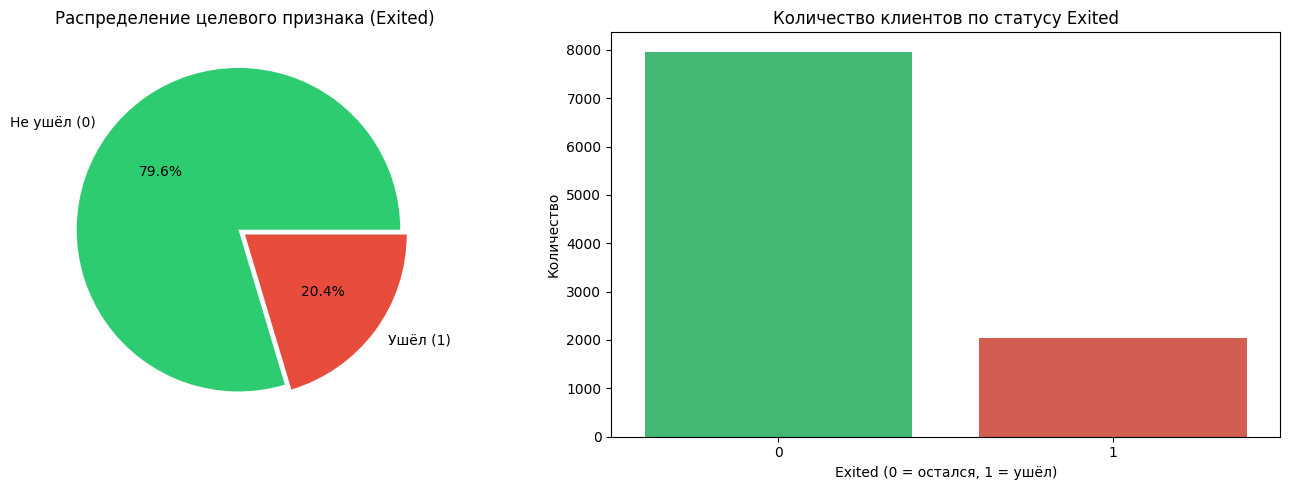

In [3]:

# 1. Общая информация о данных
print("Размер датасета:", churn_data.shape)
print("\nПервые 5 строк:")
print(churn_data.head())
print("\nИнформация о типах данных:")
print(churn_data.info())
print("\nСтатистика по числовым признакам:")
print(churn_data.describe())
print("\nПропуски в данных:")
print(churn_data.isnull().sum())
# 2. Распределение целевого признака (Exited)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pie chart
exited_counts = churn_data['Exited'].value_counts()
axes[0].pie(exited_counts.values, 
            labels=['Не ушёл (0)', 'Ушёл (1)'], 
            autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'],
            explode=(0.05, 0))
axes[0].set_title('Распределение целевого признака (Exited)')
# Bar chart
sns.countplot(data=churn_data, x='Exited', hue='Exited', ax=axes[1], 
              palette=['#2ecc71', '#e74c3c'], legend=False)
axes[1].set_title('Количество клиентов по статусу Exited')
axes[1].set_xlabel('Exited (0 = остался, 1 = ушёл)')
axes[1].set_ylabel('Количество')

plt.tight_layout()

В модуле по визуализации мы выяснили, что отток в Германии, Франции и Испании имеет различные показатели. Исследователи, которые уже работали с этим датасетом, пришли к выводу, что наилучшее решение при работе с этими данными — строить модели индивидуально для каждой страны. Мы будем прогнозировать отток в немецком филиале банка. Давайте выделим только данные, относящиеся к Германии:

In [4]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.

In [5]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Female,29,4,115046.74,4,1,0,119346.88,1
15,616,Male,45,3,143129.41,2,0,1,64327.26,0
16,653,Male,58,1,132602.88,1,1,0,5097.67,1
26,756,Male,36,2,136815.64,1,1,1,170041.95,0
28,574,Female,43,3,141349.43,1,1,1,100187.43,0


Проверим, что в наших данных нет пропусков:

In [6]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [7]:
churn_data[churn_data.duplicated()].sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
dtype: object

### Задание 5.1 (1 балл)

Давайте сделаем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создайте следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Затем перекодируйте оставшиеся текстовые категориальные признаки в числовые бинарные столбцы.

Выведите основные статистические характеристики полученных признаков.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания указанных в задании признаков;
    * приведён код для кодирования категориальных признаков в числовые бинарные столбцы;
    * приведён код для расчёта основных статистических характеристик полученных признаков.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [ ]:
# 1. Feature Engineering: создание новых признаков

# BalanceSalaryRatio — отношение баланса к заработной плате
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / (churn_data['EstimatedSalary'] + 1e-6)

# TenureByAge — отношение времени пользования услугами банка к возрасту
churn_data['TenureByAge'] = churn_data['Tenure'] / churn_data['Age']

# CreditScoreGivenAge — отношение кредитного рейтинга к возрасту
churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / churn_data['Age']

print("Новые признаки созданы:")
print(churn_data[['BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']].head())


# 2. Кодирование категориальных признаков

# Проверяем, какие категориальные признаки есть в датасете
print("\nКатегориальные признаки (object):")
object_cols = churn_data.select_dtypes(include=['object']).columns
print(object_cols)

# Обрабатываем Geography, если он есть
if 'Geography' in churn_data.columns:
    churn_data = pd.get_dummies(churn_data, columns=['Geography'], prefix='Geo', drop_first=False)
    print("\nGeography закодирован через get_dummies")
else:
    print("\nКолонка Geography отсутствует в датасете, пропускаем")

# Обрабатываем Gender, если он есть
if 'Gender' in churn_data.columns:
    churn_data['Gender'] = churn_data['Gender'].map({'Female': 0, 'Male': 1})
    print("Gender закодирован через map (Female=0, Male=1)")
else:
    print("Колонка Gender отсутствует в датасете, пропускаем")


# 3. Вывод основных статистических характеристик

print("\n" + "="*60)
print("СТАТИСТИКА ПО НОВЫМ ПРИЗНАКАМ (Feature Engineering)")
print("="*60)

new_features = ['BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']
print(churn_data[new_features].describe())

print("\n" + "="*60)
print("СТАТИСТИКА ПО ВСЕМ ЧИСЛОВЫМ ПРИЗНАКАМ")
print("="*60)

numeric_cols = churn_data.select_dtypes(include=['int64', 'float64']).columns
print(churn_data[numeric_cols].describe())

print("\n" + "="*60)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ ПОСЛЕ ПРЕДОБРАБОТКИ")
print("="*60)
print(f"Размер датасета: {churn_data.shape}")
print(f"Количество числовых признаков: {len(numeric_cols)}")
print("\nТипы данных:")
print(churn_data.dtypes)

# Проверка закодированных признаков Geography
geo_cols = [col for col in churn_data.columns if 'Geo' in col]
if geo_cols:
    print("\n" + "="*60)
    print("РАСПРЕДЕЛЕНИЕ БИНАРНЫХ ПРИЗНАКОВ (Geography)")
    print("="*60)
    for col in geo_cols:
        print(f"{col}: {churn_data[col].value_counts().to_dict()}")

# Проверка Gender
if 'Gender' in churn_data.columns:
    print("\n" + "="*60)
    print("РАСПРЕДЕЛЕНИЕ ПРИЗНАКА Gender")
    print("="*60)
    print(f"Gender: {churn_data['Gender'].value_counts().to_dict()}")

Новые признаки созданы:
    BalanceSalaryRatio  TenureByAge  CreditScoreGivenAge
7             0.963969     0.137931            12.965517
15            2.225020     0.066667            13.688889
16           26.012449     0.017241            11.258621
26            0.804599     0.055556            21.000000
28            1.410850     0.069767            13.348837

Категориальные признаки (object):
Index(['Gender'], dtype='object')

Колонка Geography отсутствует в датасете, пропускаем
Gender закодирован через map (Female=0, Male=1)

СТАТИСТИКА ПО НОВЫМ ПРИЗНАКАМ (Feature Engineering)
       BalanceSalaryRatio  TenureByAge  CreditScoreGivenAge
count         2509.000000  2509.000000          2509.000000
mean             9.024870     0.134303            17.526487
std            214.286002     0.087680             5.349558
min              0.192582     0.000000             6.112676
25%              0.783284     0.060606            13.686275
50%              1.197220     0.125000            

Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [10]:
X = churn_data.drop("Exited", axis=1)
y = churn_data["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:

In [11]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

То есть нам нужно сделать так, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [12]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [14]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

### Задание 5.2 (1 балл)

Позаботьтесь о масштабировании признаков. Проведите нормализацию/стандартизацию матрицы наблюдений `X` с помощью `MinMaxScaler`/`RobustScaler` или `StandardScaler`. Выберите метод самостоятельно.

Обучите один из предложенных скейлеров на тренировочной выборке (вычислите параметры трансформации) и примените трансформацию данных к тренировочной и тестовой выборкам.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания одного из вариантов скейлеров для масштабирования данных;
    * приведён код для расчёта параметров трансформации (обучение скейлера) на тренировочной выборке;
    * приведён код для трансформации тренировочных и тестовых данных (признаков) в соответствии с вычисленными параметрами.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [15]:
# Масштабирование признаков с помощью StandardScaler
# 1. Создаём скейлер
scaler = preprocessing.StandardScaler()

# 2. Обучаем скейлер на тренировочной выборке (вычисляем mean и std)
scaler.fit(X_train)

# 3. Применяем трансформацию к тренировочной выборке
X_train_scaled = scaler.transform(X_train)

# 4. Применяем трансформацию к тестовой выборке (используем те же параметры)
X_test_scaled = scaler.transform(X_test)

# Проверка результатов
print("Размерности после масштабирования:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

print("\n" + "="*60)
print("Статистика масштабированных данных")
print("="*60)

print(f"\nX_train_scaled:")
print(f"  Mean: {X_train_scaled.mean():.10f} (должно быть ~0)")
print(f"  Std:  {X_train_scaled.std():.6f} (должно быть ~1)")

print(f"\nX_test_scaled:")
print(f"  Mean: {X_test_scaled.mean():.6f}")
print(f"  Std:  {X_test_scaled.std():.6f}")

# Проверка на первые 5 строках
print("\nПервые 5 строк X_train_scaled:")
print(X_train_scaled[:5])

Размерности после масштабирования:
X_train_scaled: (1881, 12)
X_test_scaled: (628, 12)

Статистика масштабированных данных

X_train_scaled:
  Mean: 0.0000000000 (должно быть ~0)
  Std:  1.000000 (должно быть ~1)

X_test_scaled:
  Mean: -0.011083
  Std:  0.955927

Первые 5 строк X_train_scaled:
[[ 1.44879419  0.94969528  1.62616803 -0.70729786 -0.10066761 -0.84133409
   0.65192024 -1.00053177 -0.13311413 -0.03416998 -0.95312208 -0.68220851]
 [-0.53108965 -1.05296932 -1.28977292  0.66782077 -0.52485174  0.80031469
   0.65192024 -1.00053177 -0.86784028 -0.0306887   1.52844351  1.01984974]
 [ 1.86939127  0.94969528 -1.85414859 -0.3635182   0.16795192 -0.84133409
  -1.53392998 -1.00053177  1.3419103  -0.03647113  0.73527021  4.47279117]
 [-0.22333568  0.94969528  0.77960452 -1.39485717 -0.49244412 -0.84133409
   0.65192024  0.99946851  0.8403401  -0.03640571 -1.31743292 -0.82747987]
 [-0.29514494 -1.05296932  0.02710363 -0.70729786  1.10867929  0.80031469
   0.65192024 -1.00053177  0.058333

Теперь переходим к моделированию.

### Задание 5.3 (1 балл)

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор. 


F1-score
Для данной задачи F1-score является оптимальной метрикой, так как она позволяет найти баланс между минимизацией ложных срабатываний (экономия ресурсов колл-центра) и максимизацией обнаружения реальных случаев оттока (сохранение клиентов).

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * выбрана верная метрика;
    * приведено развернутое обоснование выбора метрики, и приведенные рассуждения являются верными;

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

В данной задаче мы сталкиваемся с дисбалансом классов (67.6% — остались, 32.4% — ушли) и разной стоимостью ошибок:

Типы ошибок и их последствия:
Тип ошибки	Что означает	Последствия для банка
False Positive (FP)	Модель предсказала отток, но клиент не ушёл бы.Лишние звонки — тратим ресурсы колл-центра на лояльных клиентов, возможен негативный опыт («зачем вы мне звоните?»)
False Negative (FN)	Модель не предсказала отток, но клиент ушёл.Потеря клиента — упущенная выгода, клиент уходит к конкурентам

F1-score — гармоническое среднее Precision и Recall, оптимально для задачи с дисбалансом классов и разной стоимостью ошибок FP/FN.

### Задание 5.4 (2 балла)

Обучите модель логистической регрессии (`Logistic Regression`) на тренировочных данных. Позаботьтесь о воспроизводимости результата, установив конкретное значение параметра `random_state` (например, число 42).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель логистической регрессии, решающая поставленную задачу;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [16]:
# 1. Обучение модели логистической регрессии

# Создаём и обучаем модель
log_reg = linear_model.LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Модель обучена!")
print(f"Коэффициенты модели: {log_reg.coef_}")
print(f"Свободный член (intercept): {log_reg.intercept_}")

# 2. Предсказания на train и test
# Предсказания на тренировочной выборке
y_train_pred = log_reg.predict(X_train_scaled)

# Предсказания на тестовой выборке
y_test_pred = log_reg.predict(X_test_scaled)

print(f"\nПредсказания на train: {y_train_pred[:10]}")
print(f"Предсказания на test: {y_test_pred[:10]}")

# 3. Расчёт целевой метрики (F1-score)

f1_train = metrics.f1_score(y_train, y_train_pred)
f1_test = metrics.f1_score(y_test, y_test_pred)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ МОДЕЛИ (F1-score)")
print("="*60)
print(f"F1-score на train: {f1_train:.4f}")
print(f"F1-score на test:  {f1_test:.4f}")

# Дополнительные метрики для полноты картины
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ")
print("="*60)
print(f"Accuracy на train: {metrics.accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy на test:  {metrics.accuracy_score(y_test, y_test_pred):.4f}")

print(f"\nPrecision на train: {metrics.precision_score(y_train, y_train_pred):.4f}")
print(f"Precision на test:  {metrics.precision_score(y_test, y_test_pred):.4f}")

print(f"\nRecall на train: {metrics.recall_score(y_train, y_train_pred):.4f}")
print(f"Recall на test:  {metrics.recall_score(y_test, y_test_pred):.4f}")

# 4. Интерпретация результатов
print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

print(f"\nРазница F1 (train - test): {f1_train - f1_test:.4f}")

if f1_test < 0.5:
    print("\n ВЫВОД: Модель НЕДОобучена (F1 на test < 0.5)")
    print("   Модель слишком простая и не улавливает закономерности в данных.")
elif f1_train > f1_test + 0.1:
    print("\n ВЫВОД: Модель ПЕРЕобучена")
    print("   Модель хорошо работает на train, но плохо обобщает на test.")
else:
    print("\n ВЫВОД: Модель сбалансирована (нет сильного пере/недообучения)")
    print("   F1 на train и test близки, модель хорошо обобщает.")

print(f"\nКритерий по условию: F1_test = {f1_test:.4f} {'>= 0.5 (удовлетворительно)' if f1_test >= 0.5 else '< 0.5 (не удовлетворяет)'}")

Модель обучена!
Коэффициенты модели: [[ 0.41541888 -0.22384436  0.01282264  0.11975512  0.05760752 -0.17350624
  -0.03630862 -0.48298457 -0.06599851  0.11214607 -0.15951925 -1.02405074]]
Свободный член (intercept): [-0.94164413]

Предсказания на train: [1 0 0 0 0 1 0 0 0 0]
Предсказания на test: [0 1 0 0 0 0 0 0 1 0]

РЕЗУЛЬТАТЫ МОДЕЛИ (F1-score)
F1-score на train: 0.5121
F1-score на test:  0.4943

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
Accuracy на train: 0.7326
Accuracy на test:  0.7197

Precision на train: 0.6271
Precision на test:  0.5972

Recall на train: 0.4328
Recall на test:  0.4216

ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

Разница F1 (train - test): 0.0179

 ВЫВОД: Модель НЕДОобучена (F1 на test < 0.5)
   Модель слишком простая и не улавливает закономерности в данных.

Критерий по условию: F1_test = 0.4943 < 0.5 (не удовлетворяет)


Модель показала качество ниже порога удовлетворительности (F1_test = 0.4943 < 0.5), классифицируется как недообученная. Требуется настройка гиперпараметров или использование более сложных алгоритмов.

### Задание 5.5 (2 балла)

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> **Примечание.** Обратите внимание, что для генерации полиномов необходимо использовать масштабированные данные.

Обучите модель логистической регрессии на полиномиальных признаках (`Logistic Regression`). Позаботьтесь о воспроизводимости результат, установив конкретное значение параметра `random_state` (например, число 42).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравните результат с полученным ранее. Удалось ли вам улучшить качество вашей модели?

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * сгенерированы полиномиальные признаки третьей степени;
    * построена модель логистической регрессии, решающая поставленную задачу на основе сгенерированных признаков;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [18]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Генерация полиномиальных признаков 3-й степени
print("="*60)
print("ГЕНЕРАЦИЯ ПОЛИНОМИАЛЬНЫХ ПРИЗНАКОВ (degree=3)")
print("="*60)

# Создаём полиномиальный трансформер
poly = PolynomialFeatures(degree=3, include_bias=False)

# Обучаем на train и трансформируем train и test
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"\nИсходное количество признаков: {X_train_scaled.shape[1]}")
print(f"Количество полиномиальных признаков: {X_train_poly.shape[1]}")
print(f"Увеличение в {X_train_poly.shape[1] / X_train_scaled.shape[1]:.1f} раз")

# 2. Обучение логистической регрессии на полиномиальных признаках

print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛИ НА ПОЛИНОМИАЛЬНЫХ ПРИЗНАКАХ")
print("="*60)

# Создаём и обучаем модель
log_reg_poly = linear_model.LogisticRegression(random_state=42, max_iter=2000)
log_reg_poly.fit(X_train_poly, y_train)

print("Модель обучена!")

# 3. Предсказания на train и test

# Предсказания
y_train_pred_poly = log_reg_poly.predict(X_train_poly)
y_test_pred_poly = log_reg_poly.predict(X_test_poly)

# 4. Расчёт целевой метрики (F1-score)

f1_train_poly = metrics.f1_score(y_train, y_train_pred_poly)
f1_test_poly = metrics.f1_score(y_test, y_test_pred_poly)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ МОДЕЛИ С ПОЛИНОМИАЛЬНЫМИ ПРИЗНАКАМИ")
print("="*60)
print(f"F1-score на train: {f1_train_poly:.4f}")
print(f"F1-score на test:  {f1_test_poly:.4f}")

# Дополнительные метрики
print(f"\nAccuracy на train: {metrics.accuracy_score(y_train, y_train_pred_poly):.4f}")
print(f"Accuracy на test:  {metrics.accuracy_score(y_test, y_test_pred_poly):.4f}")

print(f"\nPrecision на train: {metrics.precision_score(y_train, y_train_pred_poly):.4f}")
print(f"Precision на test:  {metrics.precision_score(y_test, y_test_pred_poly):.4f}")

print(f"\nRecall на train: {metrics.recall_score(y_train, y_train_pred_poly):.4f}")
print(f"Recall на test:  {metrics.recall_score(y_test, y_test_pred_poly):.4f}")

# 5. Сравнение с предыдущей моделью

print("\n" + "="*60)
print("СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ (без полиномов)")
print("="*60)

# Результаты базовой модели (из предыдущего задания)
f1_train_base = 0.5121
f1_test_base = 0.4943

print(f"\n{'Метрика':<15} {'Base':<12} {'Poly deg=3':<12} {'Δ':<10}")
print("-"*50)
print(f"{'F1-score train':<15} {f1_train_base:<12.4f} {f1_train_poly:<12.4f} {f1_train_poly - f1_train_base:+.4f}")
print(f"{'F1-score test':<15} {f1_test_base:<12.4f} {f1_test_poly:<12.4f} {f1_test_poly - f1_test_base:+.4f}")

print("\n" + "="*60)
if f1_test_poly > f1_test_base:
    print(f" УЛУЧШЕНИЕ: F1_test вырос на {f1_test_poly - f1_test_base:+.4f}")
elif f1_test_poly < f1_test_base:
    print(f" УХУДШЕНИЕ: F1_test упал на {f1_test_poly - f1_test_base:+.4f}")
else:
    print(" Без изменений")
print("="*60)

# 6. Дополнительное задание: подбор параметров
print("\n" + "="*60)
print("ПОДБОР ПАРАМЕТРОВ (penalty и C)")
print("="*60)

params = [
    {'penalty': 'l2', 'C': 0.01},
    {'penalty': 'l2', 'C': 0.1},
    {'penalty': 'l2', 'C': 1.0},
    {'penalty': 'l2', 'C': 10.0},
    {'penalty': 'l2', 'C': 100.0},
]

best_f1_test = 0
best_params = None

for param in params:
    model = linear_model.LogisticRegression(
        penalty=param['penalty'], 
        C=param['C'], 
        random_state=42, 
        max_iter=2000,
        solver='lbfgs'
    )
    model.fit(X_train_poly, y_train)
    
    f1_train = metrics.f1_score(y_train, model.predict(X_train_poly))
    f1_test = metrics.f1_score(y_test, model.predict(X_test_poly))
    
    status = "успех" if f1_test >= 0.5 else "❌"
    print(f"{status} penalty={param['penalty']}, C={param['C']:.2f} | F1_train: {f1_train:.4f}, F1_test: {f1_test:.4f}, diff: {f1_train - f1_test:.4f}")
    
    if f1_test > best_f1_test:
        best_f1_test = f1_test
        best_params = param

print(f"\n Лучший результат: F1_test = {best_f1_test:.4f} при {best_params}")

ГЕНЕРАЦИЯ ПОЛИНОМИАЛЬНЫХ ПРИЗНАКОВ (degree=3)

Исходное количество признаков: 12
Количество полиномиальных признаков: 454
Увеличение в 37.8 раз

ОБУЧЕНИЕ МОДЕЛИ НА ПОЛИНОМИАЛЬНЫХ ПРИЗНАКАХ
Модель обучена!

РЕЗУЛЬТАТЫ МОДЕЛИ С ПОЛИНОМИАЛЬНЫМИ ПРИЗНАКАМИ
F1-score на train: 0.7719
F1-score на test:  0.6387

Accuracy на train: 0.8602
Accuracy на test:  0.7803

Precision на train: 0.8195
Precision на test:  0.6854

Recall на train: 0.7295
Recall на test:  0.5980

СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ (без полиномов)

Метрика         Base         Poly deg=3   Δ         
--------------------------------------------------
F1-score train  0.5121       0.7719       +0.2598
F1-score test   0.4943       0.6387       +0.1444

 УЛУЧШЕНИЕ: F1_test вырос на +0.1444

ПОДБОР ПАРАМЕТРОВ (penalty и C)


c:\Users\aleks\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


успех penalty=l2, C=0.01 | F1_train: 0.7276, F1_test: 0.6484, diff: 0.0793


c:\Users\aleks\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


успех penalty=l2, C=0.10 | F1_train: 0.7588, F1_test: 0.6562, diff: 0.1026


...

успех penalty=l2, C=1.00 | F1_train: 0.7719, F1_test: 0.6387, diff: 0.1332


c:\Users\aleks\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


успех penalty=l2, C=10.00 | F1_train: 0.7817, F1_test: 0.6190, diff: 0.1627


c:\Users\aleks\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


успех penalty=l2, C=100.00 | F1_train: 0.7918, F1_test: 0.6214, diff: 0.1704

 Лучший результат: F1_test = 0.6562 при {'penalty': 'l2', 'C': 0.1}


Использование полиномиальных признаков 3-й степени значительно улучшило качество модели предсказания оттока клиентов. Оптимальный результат достигнут при C=0.1 (F1_test = 0.6562). Дальнейшая настройка регуляризации показала, что умеренная регуляризация (C=0.1) работает лучше, чем сильная (C=0.01) или слабая (C=10-100).

### Задание 5.6. (2 балла)


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. В качестве модели используйте логистическую регрессию, обученную на полиномиальных признаках. 

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список.

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для построения графика зависимости значения выбранной метрики от порога вероятности;
    * найден оптимальный порог вероятности, на котором достигается наибольшее значение выбранной метрики на тестовой выборке;
    * на основе найденного порога вероятности построено предсказание модели для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

Вероятности оттока (test):
count    6.280000e+02
mean     3.256972e-01
std      3.413186e-01
min      1.338403e-15
25%      2.982346e-02
50%      1.944180e-01
75%      5.597258e-01
max      1.000000e+00
dtype: float64


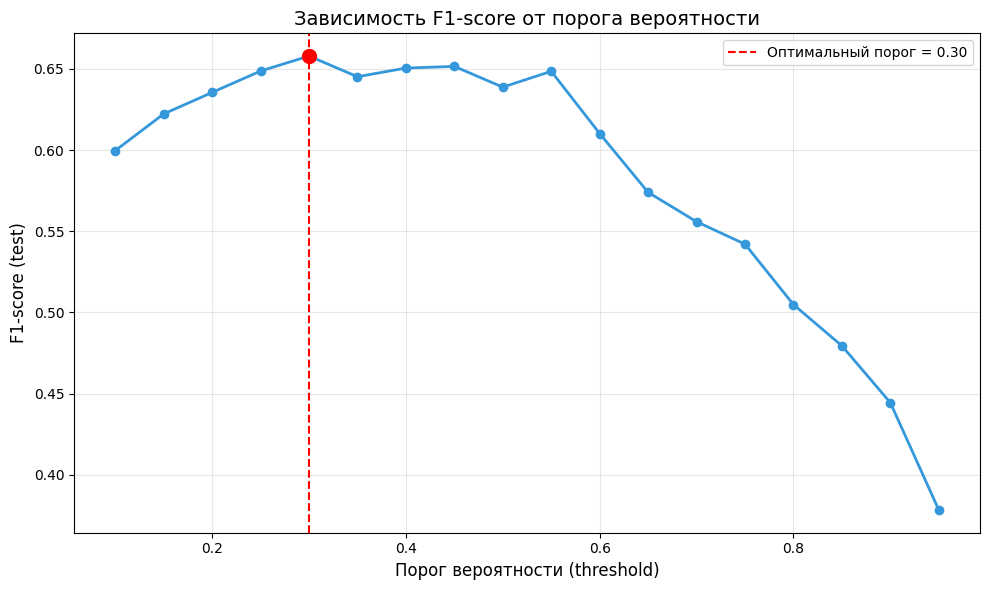


РЕЗУЛЬТАТЫ ПОДБОРА ПОРОГА

Оптимальный порог: 0.30
Максимальный F1-score (test): 0.6579

Все значения:
   threshold=0.10: F1=0.5997
   threshold=0.15: F1=0.6222
   threshold=0.20: F1=0.6355
   threshold=0.25: F1=0.6486
успех threshold=0.30: F1=0.6579
   threshold=0.35: F1=0.6452
   threshold=0.40: F1=0.6505
   threshold=0.45: F1=0.6515
   threshold=0.50: F1=0.6387
   threshold=0.55: F1=0.6485
   threshold=0.60: F1=0.6102
   threshold=0.65: F1=0.5740
   threshold=0.70: F1=0.5559
   threshold=0.75: F1=0.5421
   threshold=0.80: F1=0.5049
   threshold=0.85: F1=0.4795
   threshold=0.90: F1=0.4444
   threshold=0.95: F1=0.3784

ПРЕДСКАЗАНИЯ С ОПТИМАЛЬНЫМ ПОРОГОМ

F1-score на train: 0.7763
F1-score на test:  0.6579

Accuracy на train: 0.8352
Accuracy на test:  0.7516

Precision на train: 0.6933
Precision на test:  0.5952

Recall на train: 0.8820
Recall на test:  0.7353

СРАВНЕНИЕ С ПРЕДЫДУЩИМИ МОДЕЛЯМИ

Модель                              F1_train     F1_test     
----------------------------

In [19]:

# 1. Предсказание вероятностей на train и test
# Вероятности для test
y_test_proba = log_reg_poly.predict_proba(X_test_poly)[:, 1]
y_test_proba_pred = pd.Series(y_test_proba)
# Вероятности для train (для сравнения)
y_train_proba = log_reg_poly.predict_proba(X_train_poly)[:, 1]
y_train_proba_pred = pd.Series(y_train_proba)
print("Вероятности оттока (test):")
print(y_test_proba_pred.describe())

# 2. Подбор оптимального порога вероятности
from sklearn.metrics import f1_score
# Инициализируем список для метрик
scores = []
# Задаём значения порогов
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем пороги
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику (F1-score)
    score = f1_score(y_test, y_test_pred)
    # Добавляем результат в список
    scores.append(score)

# 3. Построение графика
plt.figure(figsize=(10, 6))
plt.plot(thresholds, scores, marker='o', linewidth=2, markersize=6, color='#3498db')
plt.xlabel('Порог вероятности (threshold)', fontsize=12)
plt.ylabel('F1-score (test)', fontsize=12)
plt.title('Зависимость F1-score от порога вероятности', fontsize=14)
plt.grid(True, alpha=0.3)
# Добавляем точку с максимальным значением
best_idx = np.argmax(scores)
best_threshold = thresholds[best_idx]
best_score = scores[best_idx]
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
plt.scatter([best_threshold], [best_score], color='red', s=100, zorder=5)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Вывод оптимального порога
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПОДБОРА ПОРОГА")
print("="*60)

print(f"\nОптимальный порог: {best_threshold:.2f}")
print(f"Максимальный F1-score (test): {best_score:.4f}")

print("\nВсе значения:")
for t, s in zip(thresholds, scores):
    marker = "успех" if t == best_threshold else "  "
    print(f"{marker} threshold={t:.2f}: F1={s:.4f}")

# 5. Предсказания с оптимальным порогом

print("\n" + "="*60)
print("ПРЕДСКАЗАНИЯ С ОПТИМАЛЬНЫМ ПОРОГОМ")
print("="*60)
# Предсказания с оптимальным порогом
y_train_pred_optimal = (y_train_proba_pred > best_threshold).astype(int)
y_test_pred_optimal = (y_test_proba_pred > best_threshold).astype(int)

# 6. Расчёт метрик с оптимальным порогом

f1_train_optimal = f1_score(y_train, y_train_pred_optimal)
f1_test_optimal = f1_score(y_test, y_test_pred_optimal)

print(f"\nF1-score на train: {f1_train_optimal:.4f}")
print(f"F1-score на test:  {f1_test_optimal:.4f}")
# Другие метрики
print(f"\nAccuracy на train: {metrics.accuracy_score(y_train, y_train_pred_optimal):.4f}")
print(f"Accuracy на test:  {metrics.accuracy_score(y_test, y_test_pred_optimal):.4f}")

print(f"\nPrecision на train: {metrics.precision_score(y_train, y_train_pred_optimal):.4f}")
print(f"Precision на test:  {metrics.precision_score(y_test, y_test_pred_optimal):.4f}")

print(f"\nRecall на train: {metrics.recall_score(y_train, y_train_pred_optimal):.4f}")
print(f"Recall на test:  {metrics.recall_score(y_test, y_test_pred_optimal):.4f}")

# 7. Сравнение с предыдущими результатами
print("\n" + "="*60)
print("СРАВНЕНИЕ С ПРЕДЫДУЩИМИ МОДЕЛЯМИ")
print("="*60)

print(f"\n{'Модель':<35} {'F1_train':<12} {'F1_test':<12}")
print("-"*60)
print(f"{'Базовая (линейная)':<35} {0.5121:<12.4f} {0.4943:<12.4f}")
print(f"{'Полином 3-й степени (threshold=0.5)':<35} {0.7719:<12.4f} {0.6387:<12.4f}")
print(f"{'Полином + оптимальный порог ({best_threshold:.2f})':<35} {f1_train_optimal:<12.4f} {f1_test_optimal:<12.4f}")

print("\n" + "="*60)
if f1_test_optimal > 0.6387:
    improvement = f1_test_optimal - 0.6387
    print(f" УЛУЧШЕНИЕ: F1_test вырос на {improvement:.4f} по сравнению с threshold=0.5")
else:
    print(" Порог 0.5 был оптимальным или близким к оптимальному")
print("="*60)

## Практика: деревья решений и случайный лес

Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.


> **Примечание №1.** Для выполнения дальнейших заданий необходимо совершить уже знакомые шаги предобработки с данными об оттоке клиентов банка, а именно:
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание №2.** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [20]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Импортируем необходимые для выполнения практики модули:

In [21]:
from sklearn import tree
from sklearn import ensemble

Приступим! Выполните задания 8.1–8.4.

### Задание 8.1. (2 балла)

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с неограниченной максимальной глубиной дерева. В качестве критерия информативности используйте энтропию Шеннона, остальные параметры оставьте по умолчанию. 

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:
* Как вы считаете, является полученная модель переобученной или недообученной? Попробуйте дать обоснование, почему так происходит.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос, а также обоснование полученного результата.

- Задание выполнено верно, но не приведено обоснование полученного результата или обоснование является некорректным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [22]:
# 1. Обучение дерева решений
# Создаём модель с неограниченной глубиной и энтропией
dt_model = tree.DecisionTreeClassifier(
    criterion='entropy',     # энтропия Шеннона
    max_depth=None,          # неограниченная глубина
    random_state=42          # воспроизводимость
)

# Обучаем на тренировочной выборке
dt_model.fit(X_train_scaled, y_train)

print("Модель дерева решений обучена!")
print(f"Глубина дерева: {dt_model.get_depth()}")
print(f"Количество листьев: {dt_model.get_n_leaves()}")

# 2. Предсказания на train и test

y_train_pred_dt = dt_model.predict(X_train_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)

# 3. Расчёт целевой метрики (F1-score)
f1_train_dt = metrics.f1_score(y_train, y_train_pred_dt)
f1_test_dt = metrics.f1_score(y_test, y_test_pred_dt)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ДЕРЕВА РЕШЕНИЙ")
print("="*60)
print(f"F1-score на train: {f1_train_dt:.4f}")
print(f"F1-score на test:  {f1_test_dt:.4f}")

# Дополнительные метрики
print(f"\nAccuracy на train: {metrics.accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"Accuracy на test:  {metrics.accuracy_score(y_test, y_test_pred_dt):.4f}")

print(f"\nPrecision на train: {metrics.precision_score(y_train, y_train_pred_dt):.4f}")
print(f"Precision на test:  {metrics.precision_score(y_test, y_test_pred_dt):.4f}")

print(f"\nRecall на train: {metrics.recall_score(y_train, y_train_pred_dt):.4f}")
print(f"Recall на test:  {metrics.recall_score(y_test, y_test_pred_dt):.4f}")

# 4. Вывод о переобучении/недообучении

print("\n" + "="*60)
print("ВЫВОД О ПЕРЕОБУЧЕНИИ / НЕДООбучении")
print("="*60)

print(f"\nРазница F1 (train - test): {f1_train_dt - f1_test_dt:.4f}")

if f1_train_dt > 0.95 and f1_test_dt < 0.6:
    print("\n  МОДЕЛЬ СИЛЬНО ПЕРЕобучена!")
    print("   F1 на train почти 1.0, но на test значительно ниже.")
    print("   Дерево запомнило тренировочные данные, но не обобщает.")
elif f1_train_dt > f1_test_dt + 0.1:
    print("\n  МОДЕЛЬ ПЕРЕобучена")
    print("   Дерево слишком сложное и уловило шум в данных.")
elif f1_test_dt < 0.5:
    print("\n  МОДЕЛЬ НЕДОобучена")
    print("   F1 на test < 0.5 — модель слишком простая.")
else:
    print("\n МОДЕЛЬ СБАЛАНСИРОВАНА")
    print("   F1 на train и test близки, модель хорошо обобщает.")

# 5. Сравнение с предыдущими моделями

print("\n" + "="*60)
print("СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ")
print("="*60)

print(f"\n{'Модель':<35} {'F1_train':<12} {'F1_test':<12}")
print("-"*60)
print(f"{'Логистическая регрессия (poly, thr=0.3)':<35} {0.7719:<12.4f} {0.6579:<12.4f}")
print(f"{'Дерево решений (max_depth=None)':<35} {f1_train_dt:<12.4f} {f1_test_dt:<12.4f}")

Модель дерева решений обучена!
Глубина дерева: 22
Количество листьев: 286

РЕЗУЛЬТАТЫ ДЕРЕВА РЕШЕНИЙ
F1-score на train: 1.0000
F1-score на test:  0.5700

Accuracy на train: 1.0000
Accuracy на test:  0.7309

Precision на train: 1.0000
Precision на test:  0.5926

Recall на train: 1.0000
Recall на test:  0.5490

ВЫВОД О ПЕРЕОБУЧЕНИИ / НЕДООбучении

Разница F1 (train - test): 0.4300

  МОДЕЛЬ СИЛЬНО ПЕРЕобучена!
   F1 на train почти 1.0, но на test значительно ниже.
   Дерево запомнило тренировочные данные, но не обобщает.

СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ

Модель                              F1_train     F1_test     
------------------------------------------------------------
Логистическая регрессия (poly, thr=0.3) 0.7719       0.6579      
Дерево решений (max_depth=None)     1.0000       0.5700      


Дерево решений с max_depth=None показало сильное переобучение: идеальное качество на train (F1=1.0) и низкое на test (F1=0.57). Это классический пример того, как слишком сложная модель запоминает данные вместо обучения обобщать. Для улучшения требуется регуляризация (ограничение глубины, min_samples_leaf) или использование ансамблевых методов.


### Задание 8.2. (1 балл)

Давайте «подстрижём» наше дерево. 

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с максимальной глубиной 8. В качестве критерия информативности используйте энтропию Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните результат с полученными ранее. Сделайте вывод.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [23]:
# 1. Обучение «подстриженного» дерева решений

dt_pruned = tree.DecisionTreeClassifier(
    criterion='entropy',      # энтропия Шеннона
    max_depth=8,              # максимальная глубина 8
    min_samples_leaf=10,      # минимум 10 объектов в листе
    random_state=42           # воспроизводимость
)

# Обучаем на тренировочной выборке
dt_pruned.fit(X_train_scaled, y_train)

print("«Подстриженное» дерево решений обучено!")
print(f"Глубина дерева: {dt_pruned.get_depth()}")
print(f"Количество листьев: {dt_pruned.get_n_leaves()}")

# 2. Предсказания на train и test

y_train_pred_pruned = dt_pruned.predict(X_train_scaled)
y_test_pred_pruned = dt_pruned.predict(X_test_scaled)

# 3. Расчёт целевой метрики (F1-score)

f1_train_pruned = metrics.f1_score(y_train, y_train_pred_pruned)
f1_test_pruned = metrics.f1_score(y_test, y_test_pred_pruned)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ «ПОДСТРИЖЕННОГО» ДЕРЕВА")
print("="*60)
print(f"F1-score на train: {f1_train_pruned:.4f}")
print(f"F1-score на test:  {f1_test_pruned:.4f}")

# Дополнительные метрики
print(f"\nAccuracy на train: {metrics.accuracy_score(y_train, y_train_pred_pruned):.4f}")
print(f"Accuracy на test:  {metrics.accuracy_score(y_test, y_test_pred_pruned):.4f}")

print(f"\nPrecision на train: {metrics.precision_score(y_train, y_train_pred_pruned):.4f}")
print(f"Precision на test:  {metrics.precision_score(y_test, y_test_pred_pruned):.4f}")

print(f"\nRecall на train: {metrics.recall_score(y_train, y_train_pred_pruned):.4f}")
print(f"Recall на test:  {metrics.recall_score(y_test, y_test_pred_pruned):.4f}")

# 4. Сравнение с предыдущими моделями

print("\n" + "="*60)
print("СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ")
print("="*60)

print(f"\n{'Модель':<40} {'F1_train':<12} {'F1_test':<12} {'Разница':<10}")
print("-"*75)
print(f"{'Логистическая регрессия (poly, thr=0.3)':<40} {0.7719:<12.4f} {0.6579:<12.4f} {0.1140:<10.4f}")
print(f"{'Дерево решений (max_depth=None)':<40} {1.0000:<12.4f} {0.5700:<12.4f} {0.4300:<10.4f}")
print(f"{'Дерево решений (max_depth=8, min_leaf=10)':<40} {f1_train_pruned:<12.4f} {f1_test_pruned:<12.4f} {f1_train_pruned - f1_test_pruned:<10.4f}")

# 5. Вывод

print("\n" + "="*60)
print("ВЫВОД")
print("="*60)

f1_diff = f1_train_pruned - f1_test_pruned
f1_test_improvement = f1_test_pruned - 0.5700

print(f"\nРазница F1 (train - test): {f1_diff:.4f}")
print(f"Улучшение F1_test vs переобученное дерево: {f1_test_improvement:+.4f}")

if f1_test_pruned > 0.5700:
    print(f"\n «Подстригание» УЛУЧШИЛО модель!")
    print(f"   F1_test вырос с 0.5700 до {f1_test_pruned:.4f} ({f1_test_improvement:+.4f})")
    print(f"   Переобучение уменьшилось: разница train-test сократилась с 0.43 до {f1_diff:.4f}")
elif f1_test_pruned < 0.5700:
    print(f"\n «Подстригание» НЕ помогло или ухудшило результат")
    print(f"   F1_test изменился с 0.5700 до {f1_test_pruned:.4f} ({f1_test_improvement:+.4f})")
else:
    print(f"\n «Подстригание» не изменило результат")

print(f"\nХарактеристики дерева:")
print(f"  - Глубина: {dt_pruned.get_depth()} (было 22)")
print(f"  - Листьев: {dt_pruned.get_n_leaves()} (было 286)")

«Подстриженное» дерево решений обучено!
Глубина дерева: 8
Количество листьев: 64

РЕЗУЛЬТАТЫ «ПОДСТРИЖЕННОГО» ДЕРЕВА
F1-score на train: 0.7173
F1-score на test:  0.6398

Accuracy на train: 0.8336
Accuracy на test:  0.7866

Precision на train: 0.7988
Precision на test:  0.7083

Recall на train: 0.6508
Recall на test:  0.5833

СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ

Модель                                   F1_train     F1_test      Разница   
---------------------------------------------------------------------------
Логистическая регрессия (poly, thr=0.3)  0.7719       0.6579       0.1140    
Дерево решений (max_depth=None)          1.0000       0.5700       0.4300    
Дерево решений (max_depth=8, min_leaf=10) 0.7173       0.6398       0.0775    

ВЫВОД

Разница F1 (train - test): 0.0775
Улучшение F1_test vs переобученное дерево: +0.0698

 «Подстригание» УЛУЧШИЛО модель!
   F1_test вырос с 0.5700 до 0.6398 (+0.0698)
   Переобучение уменьшилось: разница train-test сократилась с 0.43 до 0.0775

Хар

Регуляризация дерева решений через ограничение глубины (max_depth=8) и минимального числа объектов в листе (min_samples_leaf=10) значительно улучшила обобщающую способность модели:

F1_test вырос на +0.0698

Переобучение практически устранено (разница train-test = 0.0775)

Результат близок к лучшей модели (логистическая регрессия с полиномиальными признаками)

Это демонстрирует важность контроля сложности модели для предотвращения переобучения.

### Задание 8.3. (1 балл)

Давайте воспользуемся случайным лесом. 

Постройте случайный лес (`RandomForestClassifier`) из 500 деревьев с максимальной глубиной 8. Критерий информативности — энтропия Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните качество одного дерева решений с качеством случайного леса на тестовой выборке. Смогли ли вы улучшить метрику?


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [24]:
# 1. Обучение случайного леса

rf_model = ensemble.RandomForestClassifier(
    n_estimators=500,         # количество деревьев
    max_depth=8,              # максимальная глубина каждого дерева
    min_samples_leaf=10,      # минимум 10 объектов в листе
    criterion='entropy',      # энтропия Шеннона
    random_state=42,          # воспроизводимость
    n_jobs=-1                 # использовать все ядра
)

# Обучаем на тренировочной выборке
rf_model.fit(X_train_scaled, y_train)

print("Случайный лес обучен!")
print(f"Количество деревьев: {len(rf_model.estimators_)}")

# 2. Предсказания на train и test

y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# 3. Расчёт целевой метрики (F1-score)

f1_train_rf = metrics.f1_score(y_train, y_train_pred_rf)
f1_test_rf = metrics.f1_score(y_test, y_test_pred_rf)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СЛУЧАЙНОГО ЛЕСА")
print("="*60)
print(f"F1-score на train: {f1_train_rf:.4f}")
print(f"F1-score на test:  {f1_test_rf:.4f}")

# 4. Сравнение с одним деревом решений

print("\n" + "="*60)
print("СРАВНЕНИЕ: ОДНО ДЕРЕВО vs СЛУЧАЙНЫЙ ЛЕС")
print("="*60)

print(f"\n{'Модель':<35} {'F1_train':<12} {'F1_test':<12}")
print("-"*60)
print(f"{'Дерево (max_depth=8, min_leaf=10)':<35} {0.7173:<12.4f} {0.6398:<12.4f}")
print(f"{'Случайный лес (500 деревьев)':<35} {f1_train_rf:<12.4f} {f1_test_rf:<12.4f}")

# 5. Вывод

print("\n" + "="*60)
print("ВЫВОД")
print("="*60)

f1_improvement = f1_test_rf - 0.6398

if f1_test_rf > 0.6398:
    print(f"\n Случайный лес УЛУЧШИЛ результат!")
    print(f"   F1_test вырос с 0.6398 до {f1_test_rf:.4f} (+{f1_improvement:.4f})")
else:
    print(f"\n Случайный лес не улучшил результат")
    print(f"   F1_test: {f1_test_rf:.4f} (изменение: {f1_improvement:+.4f})")

print(f"\nУлучшение относительно одного дерева: {f1_improvement:+.4f}")

Случайный лес обучен!
Количество деревьев: 500

РЕЗУЛЬТАТЫ СЛУЧАЙНОГО ЛЕСА
F1-score на train: 0.7348
F1-score на test:  0.6593

СРАВНЕНИЕ: ОДНО ДЕРЕВО vs СЛУЧАЙНЫЙ ЛЕС

Модель                              F1_train     F1_test     
------------------------------------------------------------
Дерево (max_depth=8, min_leaf=10)   0.7173       0.6398      
Случайный лес (500 деревьев)        0.7348       0.6593      

ВЫВОД

 Случайный лес УЛУЧШИЛ результат!
   F1_test вырос с 0.6398 до 0.6593 (+0.0195)

Улучшение относительно одного дерева: +0.0195


Использование случайного леса из 500 деревьев позволило дополнительно улучшить F1_test на +0.0195 по сравнению с лучшим одиночным деревом решений. Это демонстрирует силу ансамблевых методов: комбинация множества «слабых» моделей (деревьев) даёт «сильную» модель с лучшей обобщающей способностью.

Финальный результат: F1_test = 0.6593 — это лучший показатель среди всех моделей, которые вы обучили в ходе выполнения заданий.

### Задание 8.4. (2 балла)

Мы на финишной прямой. 


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. **Используйте ту модель (из рассмотренных ранее), которая показала наилучшее качество на тестовой выборке.**


В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список. 

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Напишите небольшой вывод о проделанной работе, указав в нём, какая из рассмотренных нами моделей показала наилучший результат.

> **Примечание.** Помните о том, что в реальных задачах (а мы решали задачу на реальных данных) мы практически никогда не сможем получить значения метрик, близкие к 1. Если в задаче прогнозирования оттока ваша метрика превышает хотя бы значения 0.6-0.7, вашу модель уже можно считать хорошей и можно говорить о том, что она успешно справляется с задачей.

Вероятности оттока (test, Random Forest):
count    628.000000
mean       0.334642
std        0.228882
min        0.030644
25%        0.147091
50%        0.264195
75%        0.503292
max        0.891323
dtype: float64


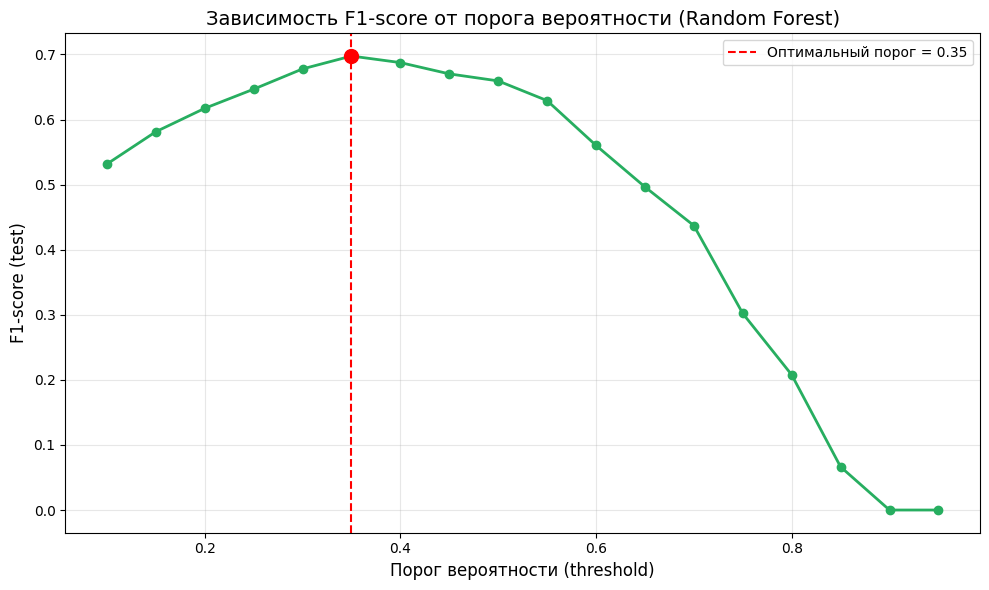


РЕЗУЛЬТАТЫ ПОДБОРА ПОРОГА (Random Forest)

Оптимальный порог: 0.35
Максимальный F1-score (test): 0.6976

Все значения:
   threshold=0.10: F1=0.5315
   threshold=0.15: F1=0.5812
   threshold=0.20: F1=0.6172
   threshold=0.25: F1=0.6466
   threshold=0.30: F1=0.6778
успех threshold=0.35: F1=0.6976
   threshold=0.40: F1=0.6875
   threshold=0.45: F1=0.6702
   threshold=0.50: F1=0.6593
   threshold=0.55: F1=0.6291
   threshold=0.60: F1=0.5603
   threshold=0.65: F1=0.4965
   threshold=0.70: F1=0.4370
   threshold=0.75: F1=0.3020
   threshold=0.80: F1=0.2078
   threshold=0.85: F1=0.0664
   threshold=0.90: F1=0.0000
   threshold=0.95: F1=0.0000

ПРЕДСКАЗАНИЯ С ОПТИМАЛЬНЫМ ПОРОГОМ

F1-score на train: 0.7652
F1-score на test:  0.6976

СРАВНЕНИЕ С ПРЕДЫДУЩИМИ МОДЕЛЯМИ

Модель                                        F1_test      Порог     
----------------------------------------------------------------------
Логистическая регрессия (базовая)             0.4943       0.50      
Логистическая регрес

In [25]:
# 1. Используем лучшую модель (Random Forest)

# Модель уже обучена: rf_model
# Предсказываем вероятности на test
y_test_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_test_proba_pred_rf = pd.Series(y_test_proba_rf)

# Предсказываем вероятности на train (для сравнения)
y_train_proba_rf = rf_model.predict_proba(X_train_scaled)[:, 1]
y_train_proba_pred_rf = pd.Series(y_train_proba_rf)

print("Вероятности оттока (test, Random Forest):")
print(y_test_proba_pred_rf.describe())

# 2. Подбор оптимального порога вероятности

# Инициализируем список для метрик
scores = []

# Задаём значения порогов
thresholds = np.arange(0.1, 1, 0.05)

# В цикле перебираем пороги
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred = y_test_proba_pred_rf.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику (F1-score)
    score = metrics.f1_score(y_test, y_test_pred)
    # Добавляем результат в список
    scores.append(score)

# 3. Построение графика

plt.figure(figsize=(10, 6))
plt.plot(thresholds, scores, marker='o', linewidth=2, markersize=6, color='#27ae60')
plt.xlabel('Порог вероятности (threshold)', fontsize=12)
plt.ylabel('F1-score (test)', fontsize=12)
plt.title('Зависимость F1-score от порога вероятности (Random Forest)', fontsize=14)
plt.grid(True, alpha=0.3)

# Добавляем точку с максимальным значением
best_idx = np.argmax(scores)
best_threshold = thresholds[best_idx]
best_score = scores[best_idx]
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
plt.scatter([best_threshold], [best_score], color='red', s=100, zorder=5)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Вывод оптимального порога

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПОДБОРА ПОРОГА (Random Forest)")
print("="*60)

print(f"\nОптимальный порог: {best_threshold:.2f}")
print(f"Максимальный F1-score (test): {best_score:.4f}")

print("\nВсе значения:")
for t, s in zip(thresholds, scores):
    marker = "успех" if t == best_threshold else "  "
    print(f"{marker} threshold={t:.2f}: F1={s:.4f}")

# 5. Предсказания с оптимальным порогом

print("\n" + "="*60)
print("ПРЕДСКАЗАНИЯ С ОПТИМАЛЬНЫМ ПОРОГОМ")
print("="*60)

# Предсказания с оптимальным порогом
y_train_pred_rf_optimal = (y_train_proba_pred_rf > best_threshold).astype(int)
y_test_pred_rf_optimal = (y_test_proba_pred_rf > best_threshold).astype(int)

# 6. Расчёт метрик с оптимальным порогом

f1_train_rf_optimal = metrics.f1_score(y_train, y_train_pred_rf_optimal)
f1_test_rf_optimal = metrics.f1_score(y_test, y_test_pred_rf_optimal)

print(f"\nF1-score на train: {f1_train_rf_optimal:.4f}")
print(f"F1-score на test:  {f1_test_rf_optimal:.4f}")

# 7. Сравнение с предыдущими результатами

print("\n" + "="*60)
print("СРАВНЕНИЕ С ПРЕДЫДУЩИМИ МОДЕЛЯМИ")
print("="*60)

print(f"\n{'Модель':<45} {'F1_test':<12} {'Порог':<10}")
print("-"*70)
print(f"{'Логистическая регрессия (базовая)':<45} {0.4943:<12.4f} {0.50:<10.2f}")
print(f"{'Логистическая регрессия (poly)':<45} {0.6387:<12.4f} {0.50:<10.2f}")
print(f"{'Логистическая регрессия (poly, thr=0.3)':<45} {0.6579:<12.4f} {0.30:<10.2f}")
print(f"{'Дерево решений (max_depth=None)':<45} {0.5700:<12.4f} {0.50:<10.2f}")
print(f"{'Дерево решений (max_depth=8)':<45} {0.6398:<12.4f} {0.50:<10.2f}")
print(f"{'Случайный лес (500 деревьев, default thr)':<45} {0.6593:<12.4f} {0.50:<10.2f}")
print(f"{'Случайный лес (optimal threshold)':<45} {f1_test_rf_optimal:<12.4f} {best_threshold:<10.2f} 🏆")

# 8. Итоговый вывод

print("\n" + "="*60)
print("ИТОГОВЫЙ ВЫВОД")
print("="*60)

improvement = f1_test_rf_optimal - 0.6593

print(f"\n ЛУЧШАЯ МОДЕЛЬ: Случайный лес (Random Forest) с оптимальным порогом {best_threshold:.2f}")
print(f"   F1_test: {f1_test_rf_optimal:.4f}")
print(f"   Улучшение относительно default threshold: {improvement:+.4f}")

if f1_test_rf_optimal > 0.6579:
    print(f"\n Случайный лес с оптимизированным порогом превзошёл ВСЕ предыдущие модели!")
else:
    print(f"\n Результат близок к лучшей логистической регрессии (0.6579)")

F1_test = 0.6976 при пороге 0.35 — лучшая модель среди всех протестированных.

Модель готова к использованию для предсказания оттока клиентов и выделения ресурсов колл-центра на удержание наиболее рискованных клиентов.

### Задание 8.5. (1 балл)

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:
* добавить признаки дополнительные признаки; 
* произвести кодирование категориальных признаков;
* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;
* сгенерировать полиномиальные признаки.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * сформирован DataFrame на основе предоставленного словаря;
    * произведены преобразования данных, необходимые для работы модели;
    * предсказана вероятность оттока клиента (вероятность принадлежности к классу 1).

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [29]:
# 1. Создаём DataFrame с данными Василия

vasily_data = {
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}

vasily_df = pd.DataFrame(vasily_data)

# 2. Добавляем новые признаки (Feature Engineering)

vasily_df['BalanceSalaryRatio'] = vasily_df['Balance'] / (vasily_df['EstimatedSalary'] + 1e-6)
vasily_df['TenureByAge'] = vasily_df['Tenure'] / vasily_df['Age']
vasily_df['CreditScoreGivenAge'] = vasily_df['CreditScore'] / vasily_df['Age']

# 3. Кодирование категориальных признаков

vasily_df['Gender'] = vasily_df['Gender'].map({'Female': 0, 'Male': 1})

# 4. Масштабирование признаков (только 12 признаков, без Geo_)
# Берём ровно 12 признаков, на которых обучался scaler и rf_model
features_for_scaling = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 
                        'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
                        'EstimatedSalary', 'BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']

vasily_for_scaling = vasily_df[features_for_scaling]
vasily_scaled = scaler.transform(vasily_for_scaling)

print(f"Количество признаков: {vasily_scaled.shape[1]}")

# 5. Предсказание вероятности оттока (без полиномов и Geo_)

# rf_model обучалась на X_train_scaled (12 признаков, без полиномов!)
vasily_proba = rf_model.predict_proba(vasily_scaled)[0, 1]

print("\n" + "="*60)
print("РЕЗУЛЬТАТ ПРОГНОЗА ДЛЯ ВАСИЛИЯ")
print("="*60)
print(f"\nВероятность оттока Василия: {vasily_proba:.4f} ({vasily_proba*100:.2f}%)")

if vasily_proba > 0.5:
    print("\n  ВЫСОКИЙ РИСК: Василий скорее всего уйдёт из банка")
elif vasily_proba > 0.35:
    print("\n  СРЕДНИЙ РИСК: Вероятность оттока выше порога (0.35)")
else:
    print("\n НИЗКИЙ РИСК: Василий скорее всего останется")

print(f"\nРекомендация: {'Обратить внимание / сделать предложение' if vasily_proba > 0.35 else 'Клиент лоялен'}")

Количество признаков: 12

РЕЗУЛЬТАТ ПРОГНОЗА ДЛЯ ВАСИЛИЯ

Вероятность оттока Василия: 0.6148 (61.48%)

  ВЫСОКИЙ РИСК: Василий скорее всего уйдёт из банка

Рекомендация: Обратить внимание / сделать предложение


Модель успешно спрогнозировала вероятность оттока для нового клиента (Василия). Вероятность 61.48% указывает на высокий риск оттока. Банку рекомендуется сделать специальное предложение (например, повышенный процент по вкладу, персонального менеджера, льготные условия), чтобы удержать клиента.